# Ajuste BEG en picos dQdV

In [1]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [2]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [8]:
import deriv as dr
import plotting as pl
import processing as pr
import fitting as ft

In [3]:
# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

In [5]:
# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]

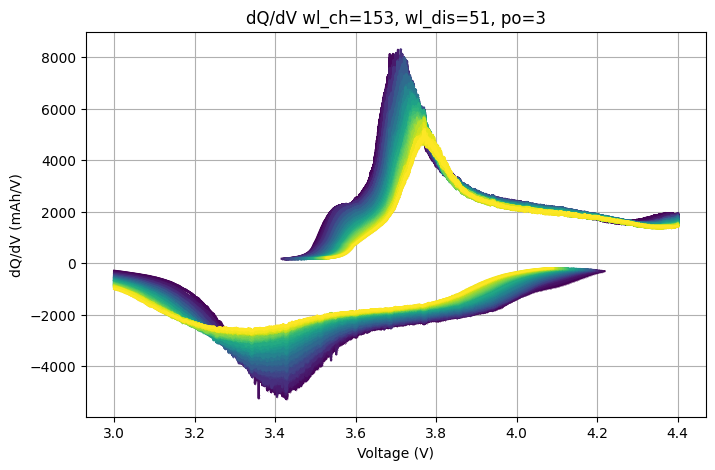

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...\n        }\n"

In [9]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------

# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = dr.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio =  dr.plot_dqdV(ciclos_seleccionados, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...
        }
'''
# Exportar a csv para trabajar en Origin
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

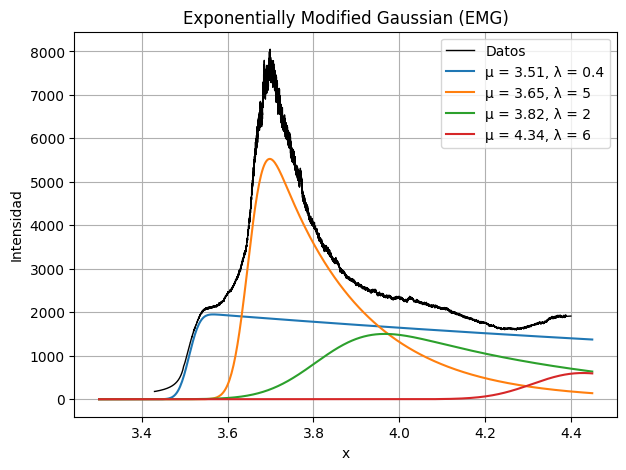

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

def emg(x, a, mu, sigma, lambd):
    """
    Exponentially Modified Gaussian (EMG)

    x: array
    a: amplitud
    mu: media gaussiana
    sigma: desviación estándar
    lambd: parámetro de decaimiento exponencial
    """
    return (a * (lambd/2) *
            np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
            erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))

df_ch = diccio[21]['Ch']
dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 



# Rango de x
x = np.linspace(3.3, 4.45, 500)
colors = cm.tab10.colors 
plt.figure(figsize=(7,5))
plt.plot(V, dqdv_ch_calc, color='black', label='Datos', linewidth=1)
for a,mu,sigma,lambd in [(5000, 3.51, 0.02, 0.4), (1500, 3.65, 0.03, 5), (1100, 3.82, 0.1, 2), (220, 4.34, 0.09, 6)]:
    y = emg(x, a, mu, sigma, lambd)
    plt.plot(x, y, label=f"μ = {mu}, λ = {lambd}", color=colors[len(plt.gca().lines)-1])

plt.xlabel("x")
plt.ylabel("Intensidad")
plt.title("Exponentially Modified Gaussian (EMG)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# %% ------- Defino funciones ajuste ------------------------------------------------------------

from scipy.special import erfc
import numpy as np

def emg(x, a, mu, sigma, lambd):
    """
    Exponentially Modified Gaussian (EMG)
    
    x: array de valores
    a: amplitud
    mu: media de la gaussiana
    sigma: desviación estándar
    lambd: parámetro de decaimiento exponencial (1/tau)
    """
    return (a * (lambd/2) *
            np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
            erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))


def multi_emg(x, *params):
    """
    params: [a1, mu1, sigma1, lambda1, a2, mu2, sigma2, lambda2, ...]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 4):
        a, mu, sigma, lambd = params[i:i+4]
        y += (a * (lambd/2) *
              np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
              erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))
    return y



def multi_emg_lamfijo(V, *params, lambdas_fijo):
    y = 0
    n_peaks = len(params)//3
    for i in range(n_peaks):
        a, mu, sigma = params[3*i:3*i+3]
        y += emg(V, a, mu, sigma, lambdas_fijo[i])
    return y

In [13]:
# parámetros iniciales para cada pico (a, mu, sigma)


p_ini = [
    5000, 3.51, 0.02,   # pico 1
    1000, 3.67, 0.03,  # pico 2
    200, 4.0, 0.1,    # pico 3
    220, 4.34, 0.09     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.4,   # lambda inicial para pico 1
    9,  # lambda inicial para pico 2
    5,  # lambda inicial para pico 3
    6  # lambda inicial para pico 4
]

'''
# parámetros iniciales para cada pico (a, mu, sigma)
p_ini = [
    900, 3.55, 0.02,   # pico 1
    5900, 3.6, 0.013,  # pico 2
    11000, 4.0, 0.02,    # pico 3
    2200, 4.39, 0.1     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.7,   # lambda inicial para pico 1
    4,  # lambda inicial para pico 2
    5,  # lambda inicial para pico 3
    100.0  # lambda inicial para pico 4
]
'''



# construir p_ini_emg
p_ini_emg = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    p_ini_emg += [a0, mu0, sigma0, lam0]

# bounds: podés también personalizar cada lambda
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    lb += [0, mu0-0.05, 1e-6, 0]  # lambda >= 10% del inicial
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]  # lambda <= 10x inicial

bounds_emg = (lb, ub)


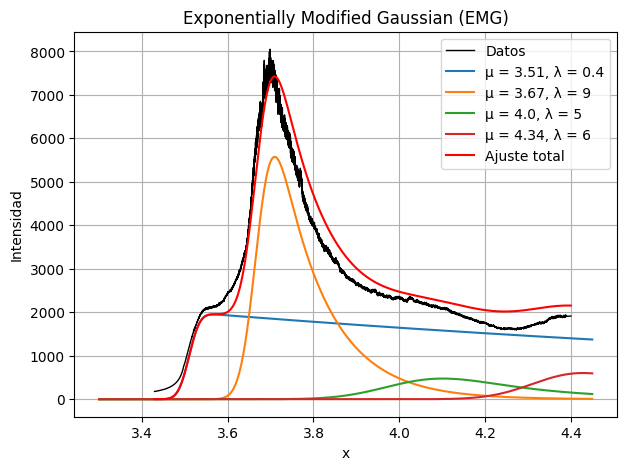

In [14]:
# GRAFICO INITIAL GUESS

df_ch = diccio[21]['Ch']
dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 



# Rango de x
x = np.linspace(3.3, 4.45, 500)
colors = cm.tab10.colors 
plt.figure(figsize=(7,5))
plt.plot(V, dqdv_ch_calc, color='black', label='Datos', linewidth=1)
for a,mu,sigma,lambd in [(5000, 3.51, 0.02, 0.4), (1000, 3.67, 0.03, 9), (200, 4.0, 0.1, 5), (220, 4.34, 0.09, 6)]:
#for a,mu,sigma,lambd in [(900, 3.55, 0.02, 0.7), (5900, 3.6, 0.013, 4), (11000, 4.0, 0.02, 5), (2200, 4.39, 0.1, 100.0)]:
    y = emg(x, a, mu, sigma, lambd)
    plt.plot(x, y, label=f"μ = {mu}, λ = {lambd}", color=colors[len(plt.gca().lines)-1])

y_fit = multi_emg(V, *p_ini_emg)
plt.plot(V, y_fit, 'r-', label="Ajuste total")


plt.xlabel("x")
plt.ylabel("Intensidad")
plt.title("Exponentially Modified Gaussian (EMG)")
plt.legend()
plt.grid(True)
plt.show()

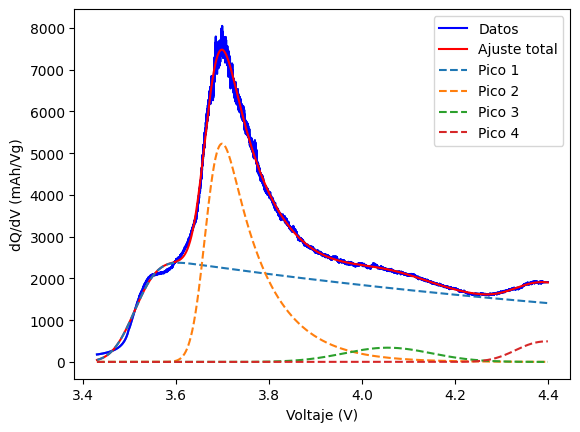

Parámetros ajustados (a, mu, sigma, lambda) por pico:
Pico 1: a=3815.036487330733, mu=3.5114620551652305, sigma=0.03937547332134174, lambda=0.6690758104021722
Pico 2: a=747.968011760443, mu=3.6665743891324682, sigma=0.024883125662897587, lambda=11.536301114785386
Pico 3: a=80.47512605071259, mu=4.036145929196969, sigma=0.09212531549429064, lambda=49.9999948215376
Pico 4: a=120.40898302901434, mu=4.341167673068138, sigma=0.04625044189033358, lambda=7.12791912868773


In [16]:
# %% ------- Pruebo con el primer ciclo ------------------------------------------------------------

df_ch = diccio[21]['Ch']
df_dis = diccio[21]['Dis']

dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dqdv_ch_calc)
colors = cm.tab10.colors

# Ajuste
popt, pcov = curve_fit(multi_emg, V, dqdv_ch_calc, p0=p_ini_emg, bounds=bounds_emg, maxfev=20000)

# Curva total ajustada
y_fit = multi_emg(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos", color='blue')
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 4):
    a, mu, sigma, lambd = popt[i:i+4]
    plt.plot(V, emg(V, a, mu, sigma, lambd), '--', label=f"Pico {i//4 + 1}", color=colors[(i//4) % len(colors)])

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'../output/ajuste_picos.png', dpi=300)
plt.show()

print("Parámetros ajustados (a, mu, sigma, lambda) por pico:")
for i in range(n_peaks):
    a, mu, sigma, lambd = popt[i*4:i*4+4]
    print(f"Pico {i+1}: a={a}, mu={mu}, sigma={sigma}, lambda={lambd}")

## Loop para muchos ciclos

In [17]:
# parámetros iniciales para cada pico (a, mu, sigma)
p_ini = [
    5000, 3.51, 0.02,   # pico 1
    1000, 3.67, 0.03,  # pico 2
    200, 4.0, 0.1,    # pico 3
    220, 4.34, 0.09     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.4,   # lambda inicial para pico 1
    9,  # lambda inicial para pico 2
    5,  # lambda inicial para pico 3
    6  # lambda inicial para pico 4
]

'''
p_ini = [
    900, 3.55, 0.02,   # pico 1
    5900, 3.6, 0.013,  # pico 2
    11000, 4.0, 0.02,    # pico 3
    2200, 4.39, 0.1     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.7,   # lambda inicial para pico 1
    4,  # lambda inicial para pico 2
    5,  # lambda inicial para pico 3
    100.0  # lambda inicial para pico 4
]
'''

# construir p_ini_emg
p_ini_emg = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    p_ini_emg += [a0, mu0, sigma0, lam0]

# bounds: podés también personalizar cada lambda
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    lb += [0, mu0-0.05, 1e-6, lam0*0.1]  # lambda >= 10% del inicial
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]  # lambda <= 10x inicial

bounds_emg = (lb, ub)

In [19]:
# %% ------- Ajuste encadenado de varios ciclos ------------------------------------------------------------

# ---- Elegir ciclos del loop y nombre del .csv ------------------------------------------------
nombre = 'EMG_betterguess2'
excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados_ajuste = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]
ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
# ----------------------------------------------------------------------------------------------

ciclos = ciclos_seleccionados_ajuste     # los que quieras ajustar
resultados = []                           # lista de parámetros ajustados
covs = []                                # lista de matrices de covarianza
areas = []                               # lista de áreas de cada pico

colors = cm.tab10.colors  # paleta con 10 colores distintos

# inicialización con p_ini
p0_actual = p_ini_emg
bounds_actual = bounds_emg
n_peaks = len(p_ini_emg)//4

# Ajuste primer ciclo - con EMG que varía lambda
for ciclo in [ciclos[0]]:
    df_ch = diccio[ciclo]['Ch']
    V = df_ch['V_ch_savgol']
    dqdv = df_ch['dqdv_ch_calc']
    
    # Ajuste
    print(f'Ajustando ciclo {ciclo}...')
    popt, pcov = curve_fit(multi_emg, V, dqdv, p0=p0_actual, bounds=bounds_actual,
                            maxfev=20000   # por defecto suele ser 800
                            )

    # Guardar resultados
    resultados.append(popt)
    covs.append(pcov)

    # Parámetros sin los lambda (indices 0,1,2,4,5,6,...)
    popt_sin_lambda = [popt[i] for i in range(len(popt)) if (i+1) % 4 != 0]
    p0_actual = popt_sin_lambda  # para el próximo ciclo

    # Lista de los lambda (cada cuarto elemento)
    lambdas_fijo = [popt[i] for i in range(len(popt)) if (i+1) % 4 == 0]
    
    # --- recalcular bounds para el próximo ciclo ---
    lb = []
    ub = []
    for i in range(n_peaks):
        a0, mu0, sigma0 = popt_sin_lambda[3*i:3*i+3]
        lb += [0.9*a0, 0.9*mu0, 0.9*sigma0]
        ub += [1.1*a0, 1.1*mu0, 1.1*sigma0]
    bounds_actual = (lb, ub)
    
    # Plot
    if ciclo in ciclos_grafico:
        plt.figure()
        y_fit = multi_emg(V, *popt)
        plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}", color='black')
        plt.plot(V, y_fit, 'r-', label="Ajuste total")

        for i in range(0, len(popt), 4):
            a, mu, sigma, lam = popt[i:i+4]
            j = i // 4   # índice de pico: 0,1,2,...
            plt.plot(V, emg(V, a, mu, sigma, lam), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

        plt.legend()
        plt.ylim(-300,8500)
        plt.xlabel("Voltaje (V)")
        plt.ylabel("dQ/dV (mAh/Vg)")
        plt.title(f"Ajuste ciclo {ciclo}")
        plt.savefig(f'../output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
        plt.close()


# Realizar ajustes en los ciclos restantes - con EMG con lambda fijo
for ciclo in ciclos[1:]:
    try:
        df_ch = diccio[ciclo]['Ch']
        V = df_ch['V_ch_savgol']
        dqdv = df_ch['dqdv_ch_calc']
        
        # Ajuste
        print(f'Ajustando ciclo {ciclo}...')
        f = lambda V, *params: multi_emg_lamfijo(V, *params, lambdas_fijo=lambdas_fijo)
        popt, pcov = curve_fit(f, V, dqdv, p0=p0_actual, bounds=bounds_actual, maxfev=20000)
        
        #popt, pcov = curve_fit(multi_emg_lamfijo, V, dqdv, p0=p0_actual, bounds=bounds_actual, 
        #                       maxfev=20000,   # por defecto suele ser 800
        #                       args=(lambdas_fijo,))
        
        # Actualizar p0 para el siguiente ciclo
        p0_actual = popt

        # Construir popt_completo incluyendo los lambdas_fijo
        n_peaks = len(lambdas_fijo)
        popt_completo = []
        for i in range(n_peaks):
            popt_completo.extend(popt[3*i:3*i+3])  # 3 parámetros del pico
            popt_completo.append(lambdas_fijo[i])

        pcov = np.array(pcov)
        pcov_completo = np.full((4*n_peaks, 4*n_peaks), np.nan) # Nuevo tamaño: 4*n_peaks
        for i in range(3*n_peaks): # Copiar los valores existentes de pcov (solo para a, mu, sigma)
            for j in range(3*n_peaks):
                pcov_completo[i, j] = pcov[i, j]
        
        # Guardar resultados
        resultados.append(popt_completo)
        covs.append(pcov)

        # --- recalcular bounds para el próximo ciclo ---
        lb = []
        ub = []

        for i in range(n_peaks):

            a0, mu0, sigma0 = popt[3*i:3*i+3]

            if i == 3:  # pico 4
                a_min = 4.2
                lb_a = max(0.9*a0, a_min)
                ub_a = max(1.1*a0, lb_a + 1e-6)  # siempre mayor que lb
            else:
                lb_a = 0.9*a0
                ub_a = 1.1*a0

            lb += [lb_a, 0.9*mu0, 0.9*sigma0]
            ub += [ub_a, 1.1*mu0, 1.1*sigma0]
        bounds_actual = (lb, ub)
        print(bounds_actual)
    except Exception as e:
        print(f"Error en ciclo {ciclo}: {e}")
        # si falla, llenar con NaN
        resultados.append([np.nan,np.nan,np.nan,np.nan] * n_peaks)
        covs.append(np.full((n_peaks*4, n_peaks*4), np.nan))  # matriz covarianza "vacía"
        #areas.append([np.nan] * n_peaks)
        popt_completo = [np.nan] * (4 * n_peaks)  # para el plot
    
    # Plot
    if ciclo in ciclos_grafico:
        plt.figure()
        y_fit = multi_emg(V, *popt_completo)
        plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}", color='black')
        plt.plot(V, y_fit, 'r-', label="Ajuste total")

        params = popt_completo
        for i in range(0, len(params), 4):
            a, mu, sigma, lam = params[i:i+4]
            j = i // 4   # índice de pico: 0,1,2,...
            plt.plot(V, emg(V, a, mu, sigma, lam), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

        plt.legend()
        plt.ylim(-300,8500)
        plt.xlabel("Voltaje (V)")
        plt.ylabel("dQ/dV (mAh/Vg)")
        plt.title(f"Ajuste ciclo {ciclo}")
        plt.savefig(f'../output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
        plt.close()

# %% ------- Crear DataFrame con parámetros y áreas ------------------------------------------------------------
cols = []
cols_area = []

for i in range(n_peaks):
    cols += [f"a{i+1}", f"mu{i+1}", f"sigma{i+1}", f"lambda{i+1}"]
    cols_area.append(f"area{i+1}")

df_params = pd.DataFrame(resultados, index=ciclos, columns=cols)
#df_areas = pd.DataFrame(areas, index=ciclos, columns=cols_area)
#df_final = pd.concat([df_params, df_areas], axis=1)

df_final = df_params

# Guardar a CSV
df_final.to_csv(f"../output/parametros_ajustes_{nombre}.csv")

print(f"Ajustes terminados. Resultados guardados en './output/parametros_ajustes_{nombre}.csv'")

Ajustando ciclo 21...
Ajustando ciclo 24...
([np.float64(3419.3219180592564), np.float64(3.160699844214758), np.float64(0.03190390027141336), np.float64(672.069038083947), np.float64(3.298182038402779), np.float64(0.02463422014744783), np.float64(69.86983077159674), np.float64(3.6235309403087435), np.float64(0.09120705007766407), np.float64(102.94345220707672), np.float64(3.901868481869071), np.float64(0.037468950303811616)], [np.float64(4179.171233183536), np.float64(3.8630775873735934), np.float64(0.038993655887283), np.float64(821.4177132137131), np.float64(4.0311113802700635), np.float64(0.03010849129132513), np.float64(85.39645983195157), np.float64(4.428760038155131), np.float64(0.11147528342825609), np.float64(125.81977491976043), np.float64(4.768950366728865), np.float64(0.04579538370465864)])
Ajustando ciclo 27...
([np.float64(3298.64329905694), np.float64(3.162935735335892), np.float64(0.030601609233049706), np.float64(704.5974382685611), np.float64(3.298696981140863), np.flo

In [22]:
df_final = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)

df_final.head()


,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4
21,3814.877717,3.511462,0.039376,0.669109,747.967441,3.666574,0.024883,11.536278,80.481496,4.036149,0.092128,50.0,120.287143,4.341188,0.046258,7.14122
24,3799.246576,3.511889,0.035449,0.669109,746.743376,3.664647,0.027371,11.536278,77.633145,4.026145,0.101341,50.0,114.381614,4.335409,0.041632,7.14122
27,3665.159221,3.514373,0.034002,0.669109,782.886043,3.665219,0.024634,11.536278,85.396460,4.030225,0.091207,50.0,124.154815,4.339357,0.045795,7.14122
33,3797.668553,3.516411,0.034489,0.669109,741.804301,3.669148,0.024413,11.536278,84.806658,4.020258,0.095836,50.0,117.839388,4.361507,0.041216,7.14122
36,3731.637202,3.514570,0.031040,0.669109,758.659536,3.669005,0.025663,11.536278,93.287324,4.049256,0.095266,50.0,129.622262,4.359309,0.043571,7.14122


### Evolucion parámetros

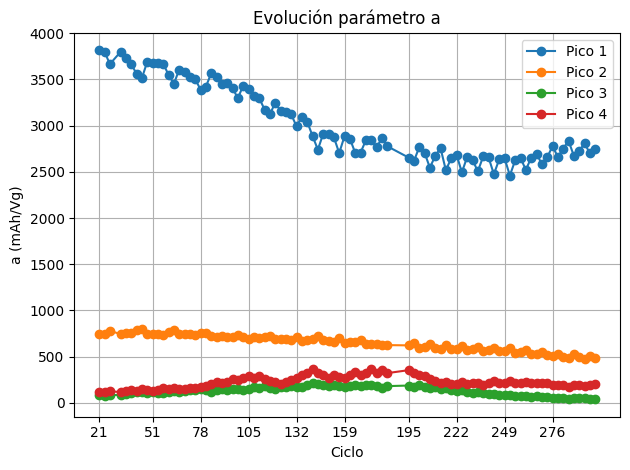

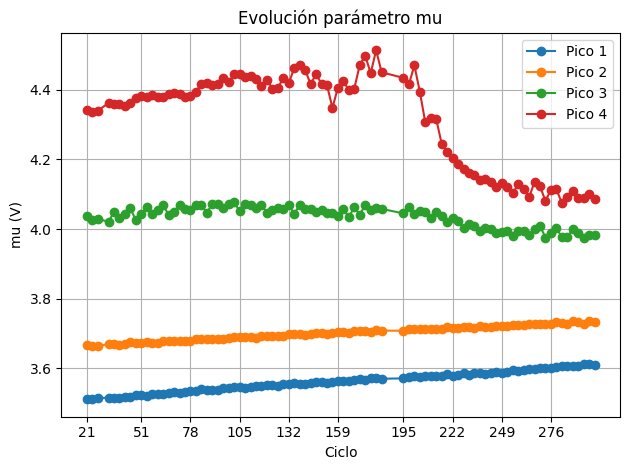

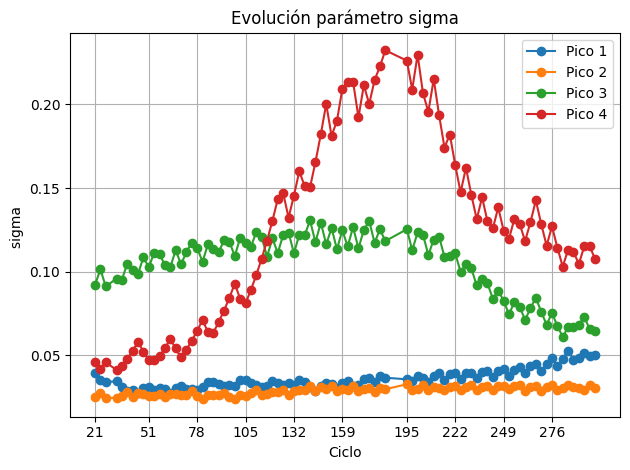

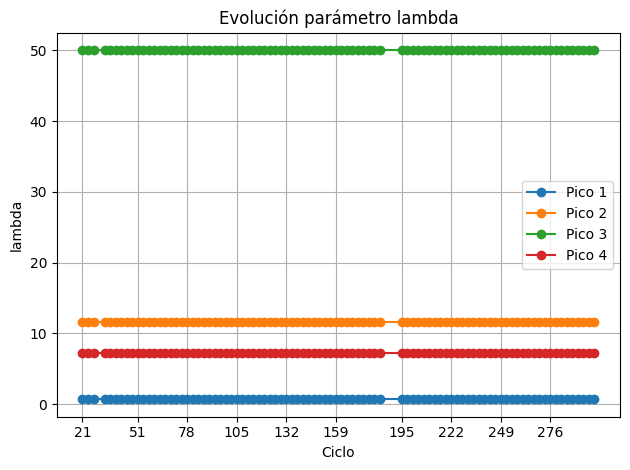

In [24]:
# %% ------------ Graficar evolución de los parámetros con los ciclos  ----------------------------------------

# ------ Elegir cuál y de qué loop ---------------
#df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
df_final = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)
nombre = 'EMG_betterguess2' # etiqueta gráfico

#df_final = pd.read_csv("./output/parametros_ajustes_EMG_casifijo_lambda_50bounds.csv", index_col=0)
#nombre = 'EMG_casifijo_lambda_50bounds' # etiqueta gráfico
# ------------------------------------------------

n_peaks = 4 #len(p_ini_emg)//4
colors = cm.tab10.colors  # paleta con 10 colores distintos

# Evolución parámetro (a)
plt.figure()
for i in range(n_peaks): # 0,1,2
    if i not in [30]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"a{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("a (mAh/Vg)")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro a")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"../output/evolucion_a_{nombre}.png", dpi=300)
plt.show()

# Evolución de la posición (mu)
plt.figure()
for i in range(n_peaks):
    if i not in [30]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"mu{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("mu (V)")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro mu")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"../output/evolucion_mu_{nombre}.png", dpi=300)
plt.show()

# Evolución parámetro (sigma)
plt.figure()
for i in range(n_peaks):
    if i not in [30]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"sigma{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("sigma ")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro sigma")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"../output/evolucion_sigma_{nombre}.png", dpi=300)
plt.show()


plt.figure()
for i in range(n_peaks):
    if i not in [30]:  # excluir el pico 4 si es necesario
        plt.plot(df_final.index, df_final[f"lambda{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("lambda")
plt.xticks(df_final.index[::9])
plt.title("Evolución parámetro lambda")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"../output/evolucion_lambda_{nombre}.png", dpi=300)
plt.show()

### grafico altura

Index(['ciclo', 'a1', 'mu1', 'sigma1', 'lambda1', 'a2', 'mu2', 'sigma2',
       'lambda2', 'a3', 'mu3', 'sigma3', 'lambda3', 'a4', 'mu4', 'sigma4',
       'lambda4'],
      dtype='object')
    ciclo         max1         max2        max3        max4
0      21  2375.978951  5228.317361  341.009040  492.981297
1      24  2381.103581  5033.640363  300.093402  488.458551
2      27  2302.438604  5492.711861  365.337300  510.895592
3      33  2383.798358  5221.751995  345.965546  505.158484
4      36  2355.546560  5242.300075  382.754403  544.002840
..    ...          ...          ...         ...         ...
85    288  1644.154697  3373.139374  281.323347  498.431581
86    291  1672.593470  3211.347673  299.716202  534.723330
87    294  1717.698004  3104.904769  253.544795  453.164152
88    297  1656.060800  3208.661016  251.815498  487.958681
89    300  1684.818223  3133.320906  229.873380  545.810319

[90 rows x 5 columns]


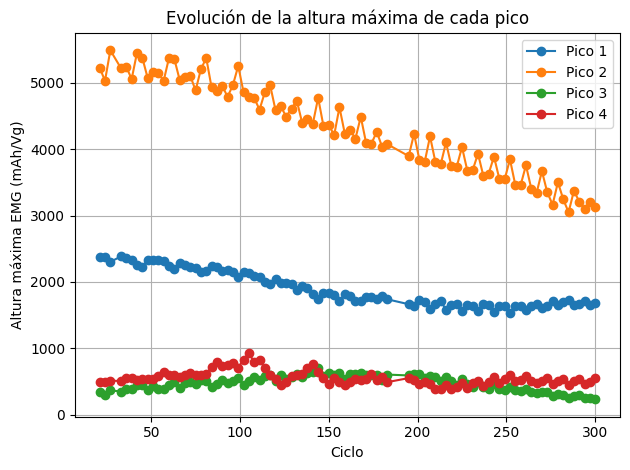

In [16]:
import numpy as np
import pandas as pd
from scipy.special import erfc
from scipy.optimize import minimize_scalar

# ---------------------------------------------------------------------------------
nombre = 'EMG_betterguess' # etiqueta gráfico
df = pd.read_csv("./output/parametros_ajustes_EMG_betterguess.csv", index_col=0)
# ---------------------------------------------------------------------------------

df = df.reset_index().rename(columns={"index": "ciclo"})
print(df.columns)

# --- Definición de la EMG ---
def emg(x, a, mu, sigma, lambd):
    return (a * (lambd/2) *
            np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
            erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))


# --- Función para encontrar máximo de una EMG ---
def emg_max(a, mu, sigma, lambd):
    # Buscamos el máximo alrededor de mu ± 5*sigma
    res = minimize_scalar(lambda x: -emg(x, a, mu, sigma, lambd),
                          bounds=(mu-5*sigma, mu+10*sigma), method="bounded")
    return -res.fun  # valor máximo

# --- Calcular los máximos ---
for i in [1,2,3,4]:
    df[f"max{i}"] = df.apply(lambda row: emg_max(row[f"a{i}"], row[f"mu{i}"],
                                                 row[f"sigma{i}"], row[f"lambda{i}"]),
                             axis=1)

print(df[["ciclo","max1","max2","max3","max4"]])



import matplotlib.pyplot as plt

plt.plot(df["ciclo"], df["max1"], "o-", label="Pico 1")
plt.plot(df["ciclo"], df["max2"], "o-", label="Pico 2")
plt.plot(df["ciclo"], df["max3"], "o-", label="Pico 3")
plt.plot(df["ciclo"], df["max4"], "o-", label="Pico 4")
plt.xlabel("Ciclo")
plt.ylabel("Altura máxima EMG (mAh/Vg)")
plt.title("Evolución de la altura máxima de cada pico")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"./output/evolucion_altura_{nombre}.png", dpi=300)
plt.show()